In [42]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [43]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [44]:
df = pd.DataFrame(X, columns=['f1','f2','f3','f4','f5'])
df['target'] = y
df.head()

,f1,f2,f3,f4,f5,target
0,0.834852,1.374379,-0.957303,-0.354347,1.583589,1
1,2.492276,3.401779,0.745552,-0.169473,0.518215,1
2,-0.369033,1.407442,0.138686,1.251994,-0.790435,0
3,0.149405,2.382053,1.825655,-1.966669,-1.261433,0
4,-0.871982,2.486343,-0.182722,0.977874,1.346669,1


In [45]:
# Sampling function for bagging.
def sample_row(df, percentage):
    return df.sample(frac=percentage, replace=True)

In [46]:
df1 = sample_row(df,0.2)
df2 = sample_row(df,0.2)
df3 = sample_row(df,0.2)

In [47]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

clf1.fit(df1.drop('target',axis=1), df1['target'])
clf2.fit(df2.drop('target',axis=1), df2['target'])
clf3.fit(df3.drop('target',axis=1), df3['target'])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.4, 0.875, 'x[4] <= 0.143\ngini = 0.495\nsamples = 20\nvalue = [11, 9]'),
 Text(0.2, 0.625, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.30000000000000004, 0.75, 'True  '),
 Text(0.6, 0.625, 'x[0] <= 0.409\ngini = 0.375\nsamples = 12\nvalue = [3, 9]'),
 Text(0.5, 0.75, '  False'),
 Text(0.4, 0.375, 'x[2] <= 0.221\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.2, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6, 0.125, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.8, 0.375, 'gini = 0.0\nsamples = 8\nvalue = [0, 8]')]

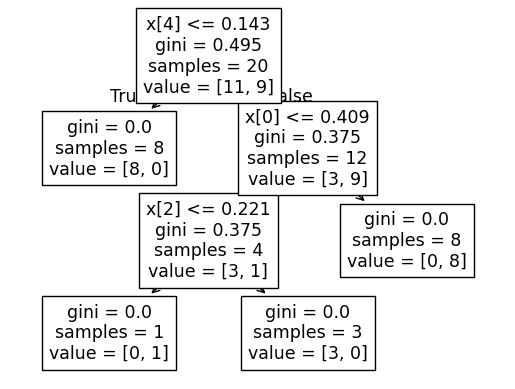

In [48]:
from sklearn.tree import plot_tree
plot_tree(clf1)

[Text(0.4, 0.8333333333333334, 'x[4] <= 0.078\ngini = 0.495\nsamples = 20\nvalue = [11, 9]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 10\nvalue = [10, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[2] <= 2.879\ngini = 0.18\nsamples = 10\nvalue = [1, 9]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]')]

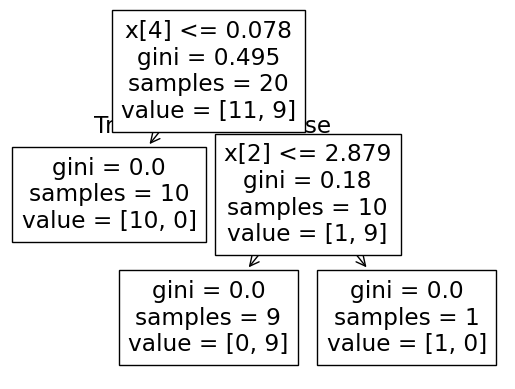

In [49]:
plot_tree(clf2)

[Text(0.6, 0.8333333333333334, 'x[4] <= -0.034\ngini = 0.48\nsamples = 20\nvalue = [8, 12]'),
 Text(0.4, 0.5, 'x[2] <= -0.148\ngini = 0.32\nsamples = 10\nvalue = [8, 2]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]'),
 Text(0.7, 0.6666666666666667, '  False')]

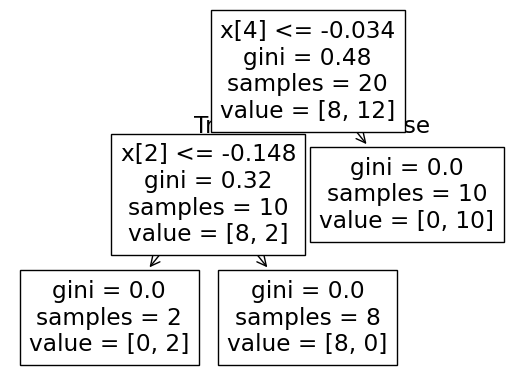

In [50]:
plot_tree(clf3)

In [51]:
print(clf1.predict(np.array([0.902154, -0.984502, 1.519123, 0.029074, -1.157267]).reshape(1,-1)))
print(clf2.predict(np.array([0.902154, -0.984502, 1.519123, 0.029074, -1.157267]).reshape(1,-1)))
print(clf3.predict(np.array([0.902154, -0.984502, 1.519123, 0.029074, -1.157267]).reshape(1,-1)))

[0]
[0]
[0]


/home/hardik/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/hardik/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/hardik/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [52]:
# function for feature sampling.

import random
def sample_features(df, percent):
    cols = random.sample( # or np.random.choice() can also be used.
        df.columns.tolist()[:-1],
        int(percent * (df.shape[1] - 1))
    )
    
    new_df = df[cols].copy()
    new_df['target'] = df['target']

    return new_df

In [53]:
df1 = sample_features(df,0.8)
df2 = sample_features(df,0.8)
df3 = sample_features(df,0.8)

clf1.fit(df1.drop('target',axis=1), df1['target'])
clf2.fit(df2.drop('target',axis=1), df2['target'])
clf3.fit(df3.drop('target',axis=1), df3['target'])
df1.head()

,f5,f3,f4,f1,target
0,1.583589,-0.957303,-0.354347,0.834852,1
1,0.518215,0.745552,-0.169473,2.492276,1
2,-0.790435,0.138686,1.251994,-0.369033,0
3,-1.261433,1.825655,-1.966669,0.149405,0
4,1.346669,-0.182722,0.977874,-0.871982,1


[Text(0.375, 0.9, 'x[0] <= 0.094\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.16666666666666666, 0.7, 'x[3] <= 2.615\ngini = 0.093\nsamples = 41\nvalue = [39, 2]'),
 Text(0.2708333333333333, 0.8, 'True  '),
 Text(0.08333333333333333, 0.5, 'gini = 0.0\nsamples = 39\nvalue = [39, 0]'),
 Text(0.25, 0.5, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.5833333333333334, 0.7, 'x[1] <= 1.252\ngini = 0.303\nsamples = 59\nvalue = [11, 48]'),
 Text(0.4791666666666667, 0.8, '  False'),
 Text(0.4166666666666667, 0.5, 'x[2] <= -2.191\ngini = 0.115\nsamples = 49\nvalue = [3, 46]'),
 Text(0.3333333333333333, 0.3, 'x[3] <= 0.539\ngini = 0.444\nsamples = 9\nvalue = [3, 6]'),
 Text(0.25, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.4166666666666667, 0.1, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.5, 0.3, 'gini = 0.0\nsamples = 40\nvalue = [0, 40]'),
 Text(0.75, 0.5, 'x[2] <= 0.239\ngini = 0.32\nsamples = 10\nvalue = [8, 2]'),
 Text(0.6666666666666666, 0.3, 'gini = 0.0

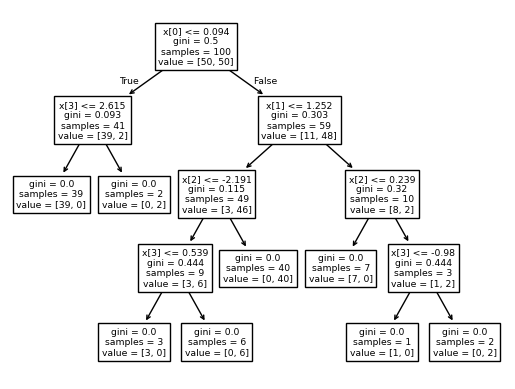

In [54]:
plot_tree(clf1)

[Text(0.6111111111111112, 0.9285714285714286, 'x[1] <= -0.066\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.3333333333333333, 0.7857142857142857, 'x[0] <= -0.804\ngini = 0.278\nsamples = 42\nvalue = [7, 35]'),
 Text(0.4722222222222222, 0.8571428571428572, 'True  '),
 Text(0.2777777777777778, 0.6428571428571429, 'x[1] <= -0.847\ngini = 0.403\nsamples = 25\nvalue = [7.0, 18.0]'),
 Text(0.16666666666666666, 0.5, 'x[0] <= -0.874\ngini = 0.219\nsamples = 16\nvalue = [2, 14]'),
 Text(0.1111111111111111, 0.35714285714285715, 'x[3] <= 2.124\ngini = 0.124\nsamples = 15\nvalue = [1, 14]'),
 Text(0.05555555555555555, 0.21428571428571427, 'gini = 0.0\nsamples = 11\nvalue = [0, 11]'),
 Text(0.16666666666666666, 0.21428571428571427, 'x[3] <= 3.279\ngini = 0.375\nsamples = 4\nvalue = [1, 3]'),
 Text(0.1111111111111111, 0.07142857142857142, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.2222222222222222, 0.07142857142857142, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.2222222222

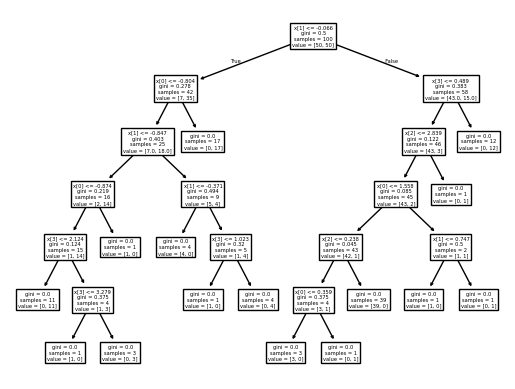

In [55]:
plot_tree(clf2)

[Text(0.4090909090909091, 0.9166666666666666, 'x[2] <= 0.094\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.18181818181818182, 0.75, 'x[0] <= 2.615\ngini = 0.093\nsamples = 41\nvalue = [39, 2]'),
 Text(0.29545454545454547, 0.8333333333333333, 'True  '),
 Text(0.09090909090909091, 0.5833333333333334, 'gini = 0.0\nsamples = 39\nvalue = [39, 0]'),
 Text(0.2727272727272727, 0.5833333333333334, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.6363636363636364, 0.75, 'x[1] <= 1.252\ngini = 0.303\nsamples = 59\nvalue = [11, 48]'),
 Text(0.5227272727272727, 0.8333333333333333, '  False'),
 Text(0.45454545454545453, 0.5833333333333334, 'x[1] <= 0.347\ngini = 0.115\nsamples = 49\nvalue = [3, 46]'),
 Text(0.36363636363636365, 0.4166666666666667, 'gini = 0.0\nsamples = 38\nvalue = [0, 38]'),
 Text(0.5454545454545454, 0.4166666666666667, 'x[0] <= 0.311\ngini = 0.397\nsamples = 11\nvalue = [3, 8]'),
 Text(0.45454545454545453, 0.25, 'x[3] <= 0.512\ngini = 0.375\nsamples = 4\nvalue = [3, 1

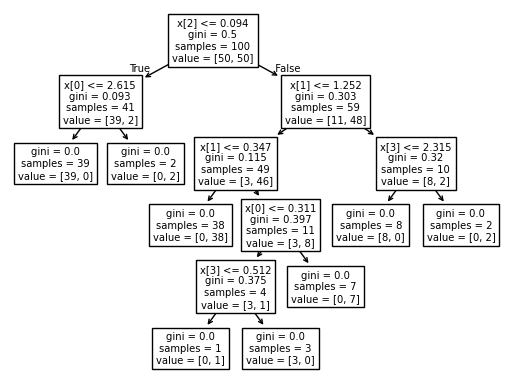

In [56]:
plot_tree(clf3)

In [57]:
print(clf1.predict(np.array([1.519123, 0.902154, -1.157267, -0.984502]).reshape(1,-1)))
print(clf2.predict(np.array([1.519123, 0.902154, -1.157267, -0.984502]).reshape(1,-1)))
print(clf3.predict(np.array([1.519123, 0.902154, -1.157267, -0.984502]).reshape(1,-1)))

[1]
[1]
[0]


/home/hardik/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/hardik/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/hardik/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [58]:
# function for combined sampling.

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_row(df,row_percent)
  return sample_features(new_df,col_percent)

In [59]:
df1 = combined_sampling(df,0.5,0.5)
df2 = combined_sampling(df,0.5,0.5)
df3 = combined_sampling(df,0.5,0.5)

In [60]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['f4', 'f1', 'target'], dtype='object')
Index(['f5', 'f1', 'target'], dtype='object')
Index(['f2', 'f1', 'target'], dtype='object')


In [61]:
df3.head()

,f2,f1,target
36,1.699414,-1.004347,0
28,1.543151,0.308210,0
31,1.358754,-0.945230,1
82,0.619028,-0.159897,1
0,1.374379,0.834852,1


In [62]:
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()
     

clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.6, 0.9375, 'x[1] <= 0.489\ngini = 0.497\nsamples = 50\nvalue = [23, 27]'),
 Text(0.4, 0.8125, 'x[0] <= 1.328\ngini = 0.444\nsamples = 33\nvalue = [22, 11]'),
 Text(0.5, 0.875, 'True  '),
 Text(0.3, 0.6875, 'x[0] <= -1.397\ngini = 0.391\nsamples = 30\nvalue = [22, 8]'),
 Text(0.2, 0.5625, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.4, 0.5625, 'x[0] <= -0.128\ngini = 0.472\nsamples = 21\nvalue = [13, 8]'),
 Text(0.2, 0.4375, 'x[1] <= -1.889\ngini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.1, 0.3125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3, 0.3125, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.6, 0.4375, 'x[1] <= -0.975\ngini = 0.245\nsamples = 14\nvalue = [12, 2]'),
 Text(0.5, 0.3125, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.7, 0.3125, 'x[1] <= -0.687\ngini = 0.375\nsamples = 8\nvalue = [6, 2]'),
 Text(0.6, 0.1875, 'x[0] <= 0.53\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.5, 0.0625, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),


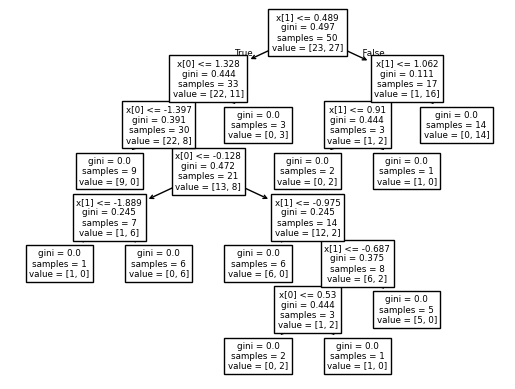

In [63]:
from sklearn.tree import plot_tree
plot_tree(clf1)

[Text(0.3333333333333333, 0.9, 'x[0] <= 0.158\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.16666666666666666, 0.7, 'gini = 0.0\nsamples = 21\nvalue = [21, 0]'),
 Text(0.25, 0.8, 'True  '),
 Text(0.5, 0.7, 'x[1] <= -2.543\ngini = 0.238\nsamples = 29\nvalue = [4, 25]'),
 Text(0.41666666666666663, 0.8, '  False'),
 Text(0.3333333333333333, 0.5, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.6666666666666666, 0.5, 'x[1] <= -0.565\ngini = 0.137\nsamples = 27\nvalue = [2, 25]'),
 Text(0.5, 0.3, 'x[0] <= 1.007\ngini = 0.375\nsamples = 8\nvalue = [2, 6]'),
 Text(0.3333333333333333, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.6666666666666666, 0.1, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.8333333333333334, 0.3, 'gini = 0.0\nsamples = 19\nvalue = [0, 19]')]

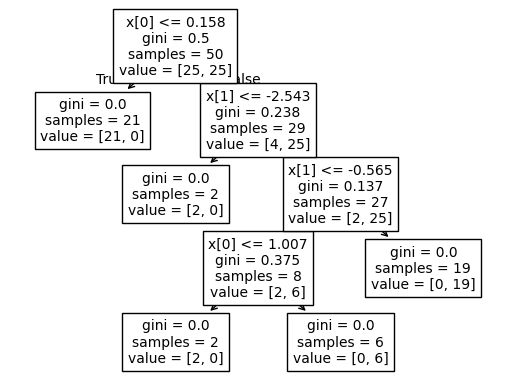

In [64]:
plot_tree(clf2)

[Text(0.4583333333333333, 0.9375, 'x[1] <= -1.001\ngini = 0.497\nsamples = 50\nvalue = [27, 23]'),
 Text(0.375, 0.8125, 'gini = 0.0\nsamples = 16\nvalue = [16, 0]'),
 Text(0.41666666666666663, 0.875, 'True  '),
 Text(0.5416666666666666, 0.8125, 'x[1] <= 0.798\ngini = 0.438\nsamples = 34\nvalue = [11, 23]'),
 Text(0.5, 0.875, '  False'),
 Text(0.25, 0.6875, 'x[1] <= -0.852\ngini = 0.5\nsamples = 18\nvalue = [9, 9]'),
 Text(0.16666666666666666, 0.5625, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.3333333333333333, 0.5625, 'x[0] <= 0.71\ngini = 0.426\nsamples = 13\nvalue = [9, 4]'),
 Text(0.16666666666666666, 0.4375, 'x[0] <= 0.218\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.08333333333333333, 0.3125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.25, 0.3125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.5, 0.4375, 'x[0] <= 1.429\ngini = 0.32\nsamples = 10\nvalue = [8, 2]'),
 Text(0.4166666666666667, 0.3125, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.5

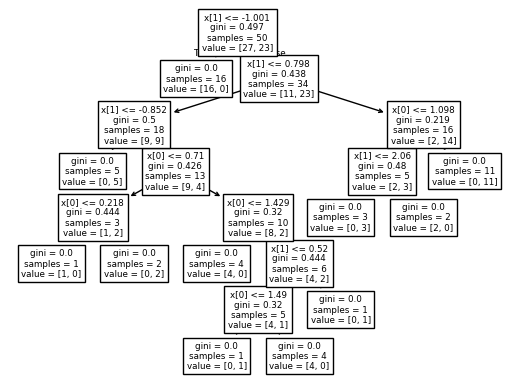

In [65]:
plot_tree(clf3)

In [66]:
print(clf1.predict(np.array([0.818794, -1.461129]).reshape(1,-1)))
print(clf2.predict(np.array([0.818794, -1.461129]).reshape(1,-1)))
print(clf3.predict(np.array([0.818794, -1.461129]).reshape(1,-1)))

[0]
[0]
[0]


/home/hardik/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/hardik/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/hardik/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [67]:
df.sample(14,replace=True)

,f1,f2,f3,f4,f5,target
39,2.411658,2.799595,1.208565,-0.643153,0.157343,1
8,2.655245,1.821355,0.532057,-2.508011,-0.566291,1
1,2.492276,3.401779,0.745552,-0.169473,0.518215,1
67,-2.247047,1.805669,2.501773,-1.474913,1.259886,0
92,1.139423,2.629155,1.110088,0.611007,0.747600,1
64,0.152479,1.858178,-0.054200,-1.582609,-1.058710,0
38,-1.263244,0.175720,0.173252,-3.566938,-0.039652,0
7,1.581499,1.566940,-2.094675,-2.491268,0.506663,1
42,0.406456,2.288752,1.295258,-0.105503,2.897947,0
37,-2.219878,1.122041,2.463974,0.680335,0.819359,0
